In [1]:
import matplotlib.pyplot as plt
import pickle
import votekit.ballot_generator as blt_gen
from votekit import PreferenceInterval
from votekit.metrics import lp_dist, earth_mover_dist
from votekit.plots import plot_MDS, compute_MDS
from joblib import Parallel, delayed
from functools import partial
# from peter_slate_emd import *
from slate_emd import *
from tqdm import tqdm

In [2]:
from optimize_helper import *

In [3]:
b_bloc_party_dict = {
    ("aberdeen", 2017, 11): [
        "Labour (Lab)",
        "Scottish National Party (SNP)",
        "Liberal Democrat (LD)",
    ],
    # ("aberdeen", 2022, 11): ["Conservative and Unionist Party (Con)", "Labour (Lab)"],
    # ("aberdeen", 2017, 10): ["Conservative and Unionist Party (Con)"],
}

file_names = {
    ("aberdeen", 2017, 11): "../election_data/aberdeen_2017_ward11.csv",
    ("aberdeen", 2022, 11): "../election_data/aberdeen_2022_ward11.csv",
    ("aberdeen", 2017, 10): "../election_data/aberdeen_2017_ward10.csv",
}


models_to_gen = {
    "n-BT": blt_gen.name_BradleyTerry,
    "n-PL": blt_gen.name_PlackettLuce,
    "s-BT": blt_gen.slate_BradleyTerry,
    "s-PL": blt_gen.slate_PlackettLuce,
    "CS-C": blt_gen.CambridgeSampler,
    "CS-W": blt_gen.CambridgeSampler,
    "solid": 0,
    "IC": blt_gen.ImpartialCulture,
    "IAC": blt_gen.ImpartialAnonymousCulture,
}

new_models = ["s-PL"]
old_models = ["solid", "IC", "IAC"]
scottish_color = ["#1560BD"]
model_to_color = {
    'CS-C': '#D2691E', 
    'CS-W': '#E32636', 
    'n-BT': '#8B008B', 
    'n-PL': '#FFB7C5', 
    's-BT': '#FFBF00', 
    's-PL': '#8DB600',
    "solid":"#09FCEE",
    "scottish": "#1560BD", 
    "IC":"#1A7601",
    "IAC":"#929292" 
}

In [4]:
def set_up_bg(
    model_str, 
    models,
    model_parameters, 
    slate_to_candidates, 
    cand_to_bloc,
    bloc_voter_prop, 
    cohesion_parameters, 
    alphas
):
    
    bg = None
    if model_str not in ["n-BT", "n-PL", "solid", "IC", "IAC"]:
        if "CS" in model_str:
            if model_str == "CS-W":
                bg = models[model_str].from_params(
                    slate_to_candidates,
                    bloc_voter_prop,
                    cohesion_parameters,
                    alphas,
                    W_bloc="B",
                    C_bloc="A",
                )
            else:
                bg = models[model_str].from_params(
                    slate_to_candidates,
                    bloc_voter_prop,
                    cohesion_parameters,
                    alphas,
                    W_bloc="A",
                    C_bloc="B",
                )
        else:
            bg = models[model_str].from_params(
                slate_to_candidates,
                bloc_voter_prop,
                cohesion_parameters,
                alphas,
            )
    elif model_str not in ["solid", "IC", "IAC"]:
        candidates = []
        for c_list in slate_to_candidates.values():
            candidates += c_list

        aa_interval = {
            f"A_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["A"]["A"].values())
        }
        ab_interval = {
            f"B_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["A"]["B"].values())
        }

        ba_interval = {
            f"A_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["B"]["A"].values())
        }
        bb_interval = {
            f"B_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["B"]["B"].values())
        }

        pref_intervals_by_bloc = {
            "A": {
                "A": PreferenceInterval(aa_interval),
                "B": PreferenceInterval(ab_interval),
            },
            "B": {
                "A": PreferenceInterval(ba_interval),
                "B": PreferenceInterval(bb_interval),
            },
        }
        bg = models[model_str](
            candidates=candidates,
            cohesion_parameters=cohesion_parameters,
            bloc_voter_prop=bloc_voter_prop,
            pref_intervals_by_bloc=pref_intervals_by_bloc,
        )

    elif model_str in ["IC", "IAC"]:
        bg = models_to_gen[model_str](candidates = list(cand_to_bloc.keys())) 

    elif model_str == "solid":
        bg=None

    else:
        raise ValueError("invalid model string")

    return bg

In [5]:
# def make_profile(
#     model_str,
#     bg,
#     slate_scottish_profile,
#     pi_a,
#     pi_b,
#     bloc_to_cand_num,
#     bloc_voter_prop,
#     n_ballots = 10000,
#     MCMC_sample_size = 10000,
# ):
#     if sum(bloc_to_cand_num.values()) >= 12 and model_str in [
#         "n-BT",
#         "s-BT",
#     ]:
#         if model_str == "n-BT":
#             profile = bg.generate_profile_MCMC(MCMC_sample_size)
#         else:
#             profile = bg.generate_profile(
#                 MCMC_sample_size, deterministic=False
#             )

#     elif model_str == "solid":
    
#         solid_profile_b = generate_solid_profile(
#             pi_b,
#             int(bloc_voter_prop["B"] * n_ballots),
#             bloc_to_cand_num,
#         )
#         solid_profile_a = generate_solid_profile(
#             pi_a,
#             int(bloc_voter_prop["A"] * n_ballots),
#             bloc_to_cand_num,
#         )
#         profile = solid_profile_a + solid_profile_b
#     else:
#         # try:
#         profile = bg.generate_profile(n_ballots)
#         # except Exception as e:
#         #     print(
#         #         f"Tried to generate profile for {model_str} with {pi_a} {pi_b} and "
#         #     )
#     return profile

In [6]:
def anonymize_slates(prefp, cand_list, cand_to_party, b_bloc_parties):
    cand_to_anon = {}

    a_count = 0
    b_count = 0
    for c in cand_list:
        if cand_to_party[c] in b_bloc_parties:
            cand_to_anon[c] = f"B_{b_count}"
            b_count += 1
        else:
            cand_to_anon[c] = f"A_{a_count}"
            a_count += 1

    bal = prefp.ballots[0]
    all_new_ballots = []
    for bal in prefp.ballots:
        for c in bal.ranking:
            if len(c) > 1:
                raise ValueError("Ties must be resolved before anonymizing")
            new_bal = Ballot(
                ranking=[{cand_to_anon[list(c)[0]]} for c in bal.ranking],
                weight=bal.weight,
            )
            all_new_ballots.append(new_bal)

    all_new_ballots
    new_pref_prof = PreferenceProfile(ballots=all_new_ballots)
    return new_pref_prof



In [7]:
def make_profile_parallel(
    election,
    file_name,
    b_bloc_party_dict,
    pi_a,
    pi_b,
    aa,
    ab,
    ba,
    bb,
    model_str,
    models_to_gen,
    MCMC_sample_size,
    n_ballots_generated = None,
):
    
    model_parameters = peter_estimate_2_bloc_parameters(
        file_name, b_bloc_party_dict[election]
    )

    scottish_profile, _, cand_list, cand_to_party, _ = load_scottish(
        file_name
    )


    if n_ballots_generated is None:
        n_ballots_generated = scottish_profile.num_ballots()


    cand_to_bloc = {
        c: "B" if cand_to_party[c] in b_bloc_party_dict[election] else "A"
        for c in cand_list
    }

    # count the number of candidates in each bloc
    bloc_to_cand_num = {
        "A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"]),
    }

    # try a one bloc model, where cohesion is percentage of first place votes
    slate_to_candidates = {
        b: [f"{b}_{i}" for i in range(bloc_to_cand_num[b])]
        for b in bloc_to_cand_num.keys()
    }
    cand_to_bloc = {c: b for b, c_list in slate_to_candidates.items() for c in c_list}

    bloc_voter_prop = {
        "A": model_parameters["bloc_first"]["A"],
        "B": model_parameters["bloc_first"]["B"],
    }

    a_cands = list(model_parameters["pref_intervals"]["A"]["A"].keys())
    b_cands = list(model_parameters["pref_intervals"]["B"]["B"].keys())

    cohesion_parameters = {
        "A": {"A": pi_a, "B": 1 - pi_a},
        "B": {"B": pi_b, "A": 1 - pi_b},
    }

    alphas = {"A": {"A": aa, "B": ab}, "B": {"B": bb, "A": ba}}

    if model_str not in ["solid", "IC", "IAC", "CS-C", "CS-W"]:

        new_params = {x: {y: {} for y in ["A", "B"]} for x in ["A", "B"]}

        new_params["A"]["A"] = dict(PreferenceInterval.from_dirichlet(a_cands, aa).interval)
        new_params["A"]["B"] = dict(PreferenceInterval.from_dirichlet(b_cands, ab).interval)
        new_params["B"]["A"] = dict(PreferenceInterval.from_dirichlet(a_cands, ba).interval)
        new_params["B"]["B"] = dict(PreferenceInterval.from_dirichlet(b_cands, bb).interval)

        model_parameters["pref_intervals"] = new_params

    bg = set_up_bg(
        model_str=model_str,
        models=models_to_gen,
        model_parameters=model_parameters,
        slate_to_candidates=slate_to_candidates,
        bloc_voter_prop=bloc_voter_prop,
        cohesion_parameters=cohesion_parameters,
        cand_to_bloc=cand_to_bloc,
        alphas=alphas,
    )

    if sum(bloc_to_cand_num.values()) >= 12 and model_str in [
        "n-BT",
        "s-BT",
    ]:
        if model_str == "n-BT":
            profile = bg.generate_profile_MCMC(MCMC_sample_size)
        else:
            profile = bg.generate_profile(MCMC_sample_size, deterministic=False)

    elif model_str == "solid":
        solid_profile_b = generate_solid_profile(
            pi_b,
            int(bloc_voter_prop["B"] * n_ballots_generated),
            bloc_to_cand_num,
        )
        solid_profile_a = generate_solid_profile(
            pi_a,
            int(bloc_voter_prop["A"] * n_ballots_generated),
            bloc_to_cand_num,
        )
        profile = solid_profile_a + solid_profile_b
    else:
        try:
            profile = bg.generate_profile(int(n_ballots_generated))
        except Exception as e:
            print(
                f"Tried to generate profile for {model_str} with {pi_a} {pi_b} and it failed"
                f" with error {e}"
            )

            
    return profile

In [8]:
from joblib import Parallel, delayed
from joblib_progress import joblib_progress as jp

def process_profile(model_str, election, file_name, pi_a, pi_b, aa, ab, ba, bb, n_ballots_generated, MCMC_sample_size=10000):
    profile = make_profile_parallel(
        election,
        file_name,
        b_bloc_party_dict,
        pi_a,
        pi_b,
        aa,
        ab,
        ba,
        bb,
        model_str,
        models_to_gen,
        MCMC_sample_size,
        n_ballots_generated,
    )
    return election, model_str, profile

In [9]:
# MCMC_sample_size = 10000


# all_models = new_models + old_models

# ward_to_profile_dict = {k: {kk: [] for kk in all_models} for k in b_bloc_party_dict.keys()}


# pi_vals = [0.55, 0.65, 0.75, 0.85, 0.95]
# pi_to_try = list(itertools.product(pi_vals, repeat=2))
# alpha_vals = [0.5, 1, 2]
# alpha_to_try = list(itertools.product(alpha_vals, repeat=4))


# n_ballots_generated = 50000

# n_items = len(pi_to_try) * len(alpha_to_try) * len(new_models) * len(file_names)


# with jp("Computing", total = n_items):
#     results = Parallel(n_jobs=-1)(
#         delayed(process_profile)(
#             model_str, election, file_name, pi_a, pi_b, aa, ab, ba, bb, n_ballots_generated
#         ) for model_str in new_models
#         for election, file_name in file_names.items()
#         for pi_a, pi_b in pi_to_try
#         for aa, ab, ba, bb in alpha_to_try
#     )




In [10]:
# n_items = 20 * len(old_models) * len(file_names)

# n_ballots_generated = 50000

# with jp("Computing", total = n_items):
#     results2 = Parallel(n_jobs=-1)(
#         delayed(process_profile)(
#             model_str=model_str, 
#             election=election,
#             file_name=file_name, 
#             pi_a=0,
#             pi_b=0,
#             aa=0,
#             ab=0,
#             ba=0,
#             bb=0,
#             n_ballots_generated=n_ballots_generated
#         ) for model_str in old_models
#         for election, file_name in file_names.items()
#         for _ in range(20)
#     )



# # # print(len(results), len(results2))

# results3=results+results2

# Comment the next results back in later

In [11]:
# import pickle
# with open("new_sweep_results_50k_solid_all.pkl", "wb") as f:
#     pickle.dump(results3, f)


# raise ValueError("STOP")

# results = None

# with open("new_sweep_results_50k_solid_all.pkl", "rb") as f:
#     results = pickle.load(f)

# print(len(results))

In [12]:
# new_results = [item for item in results if item[1] == "s-PL"]
# len(new_results)

# results = new_results + results2

# len(results)

In [13]:
# all_models = new_models + old_models
# ward_to_profile = {k: {kk: [] for kk in all_models} for k in file_names.keys()}

# for election, model_str, profile in results:
#     ward_to_profile[election][model_str].append(profile)

# del ward_to_profile[('aberdeen', 2017, 11)]["solid"]

# ward_to_profile[('aberdeen', 2017, 11)].keys()

In [14]:
# data = None
# election = ('aberdeen', 2017, 11)

# for election, file_name in file_names.items():
#     pickle_file = f"distance_data/2_bloc/emd_to_scottish_aberdeen ward_{election[2]} {election[1]}_two_bloc_optimized_s-PL_bloc_order_AB.pkl"

#     with open(pickle_file, "rb") as f:
#         data = pickle.load(f)
        

#     pi_a, pi_b = data

#     file_name = "../election_data/aberdeen_2017_ward11.csv"
#     b_bloc_parties = b_bloc_party_dict[('aberdeen', 2017, 11)]


#     mod_params = peter_estimate_2_bloc_parameters(file_name, b_bloc_parties)

#     scottish_profile, _, cand_list, cand_to_party, _ = load_scottish(
#         file_name
#     )

#     slate_scottish_profile = anonymize_slates(
#         scottish_profile,
#         cand_list,
#         cand_to_party,
#         b_bloc_parties,
#     )


#     cand_to_bloc = {
#         c: "B" if cand_to_party[c] in b_bloc_party_dict[election] else "A"
#         for c in cand_list
#     }

#     # count the number of candidates in each bloc
#     bloc_to_cand_num = {
#         "A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
#         "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"]),
#     }

#     # try a one bloc model, where cohesion is percentage of first place votes
#     slate_to_candidates = {
#         b: [f"{b}_{i}" for i in range(bloc_to_cand_num[b])]
#         for b in bloc_to_cand_num.keys()
#     }

#     bloc_voter_prop = {
#         "A": mod_params["bloc_first"]["A"],
#         "B": mod_params["bloc_first"]["B"],
#     }

#     a_cands = list(mod_params["pref_intervals"]["A"]["A"].keys())
#     b_cands = list(mod_params["pref_intervals"]["B"]["B"].keys())

#     cohesion_parameters = {
#         "A": {"A": pi_a, "B": 1 - pi_a},
#         "B": {"B": pi_b, "A": 1 - pi_b},
#     }

#     aa_interval = {
#         f"A_{i}": p
#         for i, p in enumerate(mod_params["pref_intervals"]["A"]["A"].values())
#     }
#     ab_interval = {
#         f"B_{i}": p
#         for i, p in enumerate(mod_params["pref_intervals"]["A"]["B"].values())
#     }

#     ba_interval = {
#         f"A_{i}": p
#         for i, p in enumerate(mod_params["pref_intervals"]["B"]["A"].values())
#     }
#     bb_interval = {
#         f"B_{i}": p
#         for i, p in enumerate(mod_params["pref_intervals"]["B"]["B"].values())
#     }


#     candidates = []
#     for c_list in slate_to_candidates.values():
#         candidates += c_list

#     pref_intervals_by_bloc = {
#         "A": {
#             "A": PreferenceInterval(aa_interval),
#             "B": PreferenceInterval(ab_interval),
#         },
#         "B": {
#             "A": PreferenceInterval(ba_interval),
#             "B": PreferenceInterval(bb_interval),
#         },
#     }

#     alphas = {
#         "A": {"A": 1, "B": 1},
#         "B": {"B": 1, "A": 1}
#     }

#     bg = blt_gen.slate_PlackettLuce.from_params(
#         slate_to_candidates,
#         bloc_voter_prop,
#         cohesion_parameters,
#         alphas,
#     )

#     profile = bg.generate_profile(50000)


#     ward_to_profile[election]["s-PL-peter"] = [profile]


In [15]:
# with open("full_ward_to_prof_50k_solid_all2.pkl", "wb") as f:
#     pickle.dump(ward_to_profile, f)


ward_to_profile = {}
with open("full_ward_to_prof_50k_solid_all.pkl", "rb") as f:
    ward_to_profile = pickle.load(f)

In [16]:
# del ward_to_profile[('aberdeen', 2017, 10)]
# del ward_to_profile[('aberdeen', 2022, 11)]

In [17]:
# orig_ward_to_profile = copy.deepcopy(ward_to_profile)

In [18]:
# ward_to_profile = copy.deepcopy(orig_ward_to_profile)

In [19]:
# del ward_to_profile[('aberdeen', 2017, 11)]["solid"]
del ward_to_profile[('aberdeen', 2017, 11)]["IAC"]
del ward_to_profile[('aberdeen', 2017, 11)]["s-PL-peter"]
# del ward_to_profile[('aberdeen', 2017, 11)]["s-PL"]

In [20]:
ward_to_profile[('aberdeen', 2017, 11)].keys()

dict_keys(['s-PL', 'solid', 'IC'])

In [21]:
# del ward_to_profile[('aberdeen', 2017, 11)]["scottish"]

In [22]:
ward_to_coords = {}
sp = None
for key, file_name in list(file_names.items())[:]: 
    print(key)
    city, year, ward = key

    scottish_profile, _, cand_list, cand_to_party, _ = load_scottish(file_name)


    scottish_profile = anonymize_slates(scottish_profile, cand_list, cand_to_party, b_bloc_party_dict[key])
   
    # the data is a dictionary whose keys correspond to data labels
    # and whose values are lists of PreferenceProfiles
    data =  {model_str:profiles[:] for model_str, profiles in ward_to_profile[key].items()}

    data.update({"scottish":[scottish_profile]})
    # ward_to_profile[key]["scottish"] = [scottish_profile]


    n_b_cands = sum(cand_to_party[c] in b_bloc_party_dict[key] for c in cand_list)
    n_a_cands = len(cand_list) - n_b_cands
    
    slate_dict = {
        "A": [f"A_{i}" for i in range(n_a_cands)],
        "B": [f"B_{i}" for i in range(n_b_cands)],
    }
    slate_emd = partial(slate_earth_mover_dist, slate_dict=slate_dict)
    coord_dict = compute_MDS(
        data =data, 
        distance = slate_emd,
        random_seed=47
    )
    
    
    ward_to_coords[key]=coord_dict

('aberdeen', 2017, 11)


100%|██████████| 2216565/2216565 [05:50<00:00, 6318.76it/s]


('aberdeen', 2022, 11)


KeyError: ('aberdeen', 2022, 11)

In [ ]:
# ward_to_profile[(('aberdeen', 2017, 11))]["IC"][0]

# ward_to_profile[(('aberdeen', 2017, 11))]["scottish"][0]

PreferenceProfile too long, only showing 15 out of 196 rows.


        Ballots Weight
         (B_2,)    570
         (B_1,)    436
     (B_2, A_0)    435
     (B_2, A_0)    435
         (A_0,)    423
     (A_0, B_2)    379
     (A_0, B_2)    379
(B_2, A_0, B_0)    257
(B_2, A_0, B_0)    257
(B_2, A_0, B_0)    257
(A_0, B_2, B_0)    248
(A_0, B_2, B_0)    248
(A_0, B_2, B_0)    248
     (B_1, B_2)    213
     (B_1, B_2)    213

In [ ]:
# from votekit.plots.mds import distance_matrix

# slate_dict = {
#     "A": [f"A_{i}" for i in range(n_a_cands)],
#     "B": [f"B_{i}" for i in range(n_b_cands)],
# }

# slate_emd = partial(slate_earth_mover_dist, slate_dict=slate_dict)

# pp_list = ward_to_profile[('aberdeen', 2017, 11)]["IC"]

# dist_mat = distance_matrix(pp_list, slate_emd) 

# dist_mat

100%|██████████| 780/780 [00:00<00:00, 5945.44it/s]


array([[0.     , 0.01032, 0.00182, ..., 0.01072, 0.00976, 0.00562],
       [0.01032, 0.     , 0.00894, ..., 0.00316, 0.0052 , 0.01594],
       [0.00182, 0.00894, 0.     , ..., 0.00934, 0.00834, 0.007  ],
       ...,
       [0.01072, 0.00316, 0.00934, ..., 0.     , 0.00656, 0.01634],
       [0.00976, 0.0052 , 0.00834, ..., 0.00656, 0.     , 0.01082],
       [0.00562, 0.01594, 0.007  , ..., 0.01634, 0.01082, 0.     ]])

In [ ]:
# sdfsda

In [ ]:
# len(dist_mat)

40

In [ ]:
# import pandas as pd 
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

In [ ]:
# def recursive_sort_matrix(df):
#     # Base case: if the matrix is 1x1 or empty, return it as is
#     if df.shape[0] <= 1:
#         return df
    
#     # Step 1: Sort the first row and rearrange the matrix accordingly
#     sorted_indices = df.iloc[0].argsort()
#     df_sorted = df.iloc[sorted_indices, sorted_indices]

#     # Step 2: Extract the submatrix excluding the first row and column
#     submatrix = df_sorted.iloc[1:, 1:]

#     # Step 3: Recursively sort the submatrix
#     submatrix_sorted = recursive_sort_matrix(submatrix)

#     # Step 4: Reconstruct the matrix
#     # Reconstruct the final matrix with the sorted submatrix
#     df_final = df_sorted.copy()
#     df_final.iloc[1:, 1:] = submatrix_sorted.values

#     return df_final

In [ ]:
# df = pd.DataFrame(dist_mat)

# sorted_indices = df.iloc[0].argsort()

# df = df.iloc[sorted_indices, sorted_indices]

# df

,0,14,2,30,17,21,9,26,28,35,...,34,37,29,13,25,12,18,3,15,7
0,0.00000,0.00146,0.00182,0.00254,0.00350,0.00358,0.00414,0.00444,0.00452,0.00464,...,0.01044,0.01072,0.01086,0.01104,0.01162,0.01164,0.01230,0.01266,0.01316,0.01454
14,0.00146,0.00000,0.00328,0.00272,0.00360,0.00360,0.00492,0.00578,0.00586,0.00598,...,0.01046,0.01074,0.01088,0.01106,0.01164,0.01166,0.01232,0.01268,0.01318,0.01456
2,0.00182,0.00328,0.00000,0.00112,0.00212,0.00220,0.00552,0.00266,0.00274,0.00338,...,0.00906,0.00934,0.00948,0.00966,0.01024,0.01026,0.01092,0.01128,0.01178,0.01316
30,0.00254,0.00272,0.00112,0.00000,0.00152,0.00156,0.00616,0.00370,0.00378,0.00450,...,0.00842,0.00870,0.00884,0.00902,0.00960,0.00962,0.01028,0.01064,0.01114,0.01252
17,0.00350,0.00360,0.00212,0.00152,0.00000,0.00048,0.00764,0.00338,0.00242,0.00482,...,0.00694,0.00722,0.00736,0.00754,0.00812,0.00814,0.00880,0.00916,0.00966,0.01104
21,0.00358,0.00360,0.00220,0.00156,0.00048,0.00000,0.00772,0.00338,0.00266,0.00482,...,0.00686,0.00714,0.00728,0.00746,0.00804,0.00806,0.00872,0.00908,0.00958,0.01096
9,0.00414,0.00492,0.00552,0.00616,0.00764,0.00772,0.00000,0.00686,0.00802,0.00466,...,0.01458,0.01486,0.01500,0.01518,0.01576,0.01578,0.01644,0.01680,0.01730,0.01868
26,0.00444,0.00578,0.00266,0.00370,0.00338,0.00338,0.00686,0.00000,0.00116,0.00220,...,0.00772,0.00800,0.00814,0.00992,0.00890,0.00892,0.00958,0.00994,0.01044,0.01182
28,0.00452,0.00586,0.00274,0.00378,0.00242,0.00266,0.00802,0.00116,0.00000,0.00336,...,0.00656,0.00684,0.00698,0.00896,0.00774,0.00776,0.00842,0.00878,0.00928,0.01066
35,0.00464,0.00598,0.00338,0.00450,0.00482,0.00482,0.00466,0.00220,0.00336,0.00000,...,0.00992,0.01020,0.01034,0.01136,0.01110,0.01112,0.01178,0.01214,0.01264,0.01402


<Axes: >

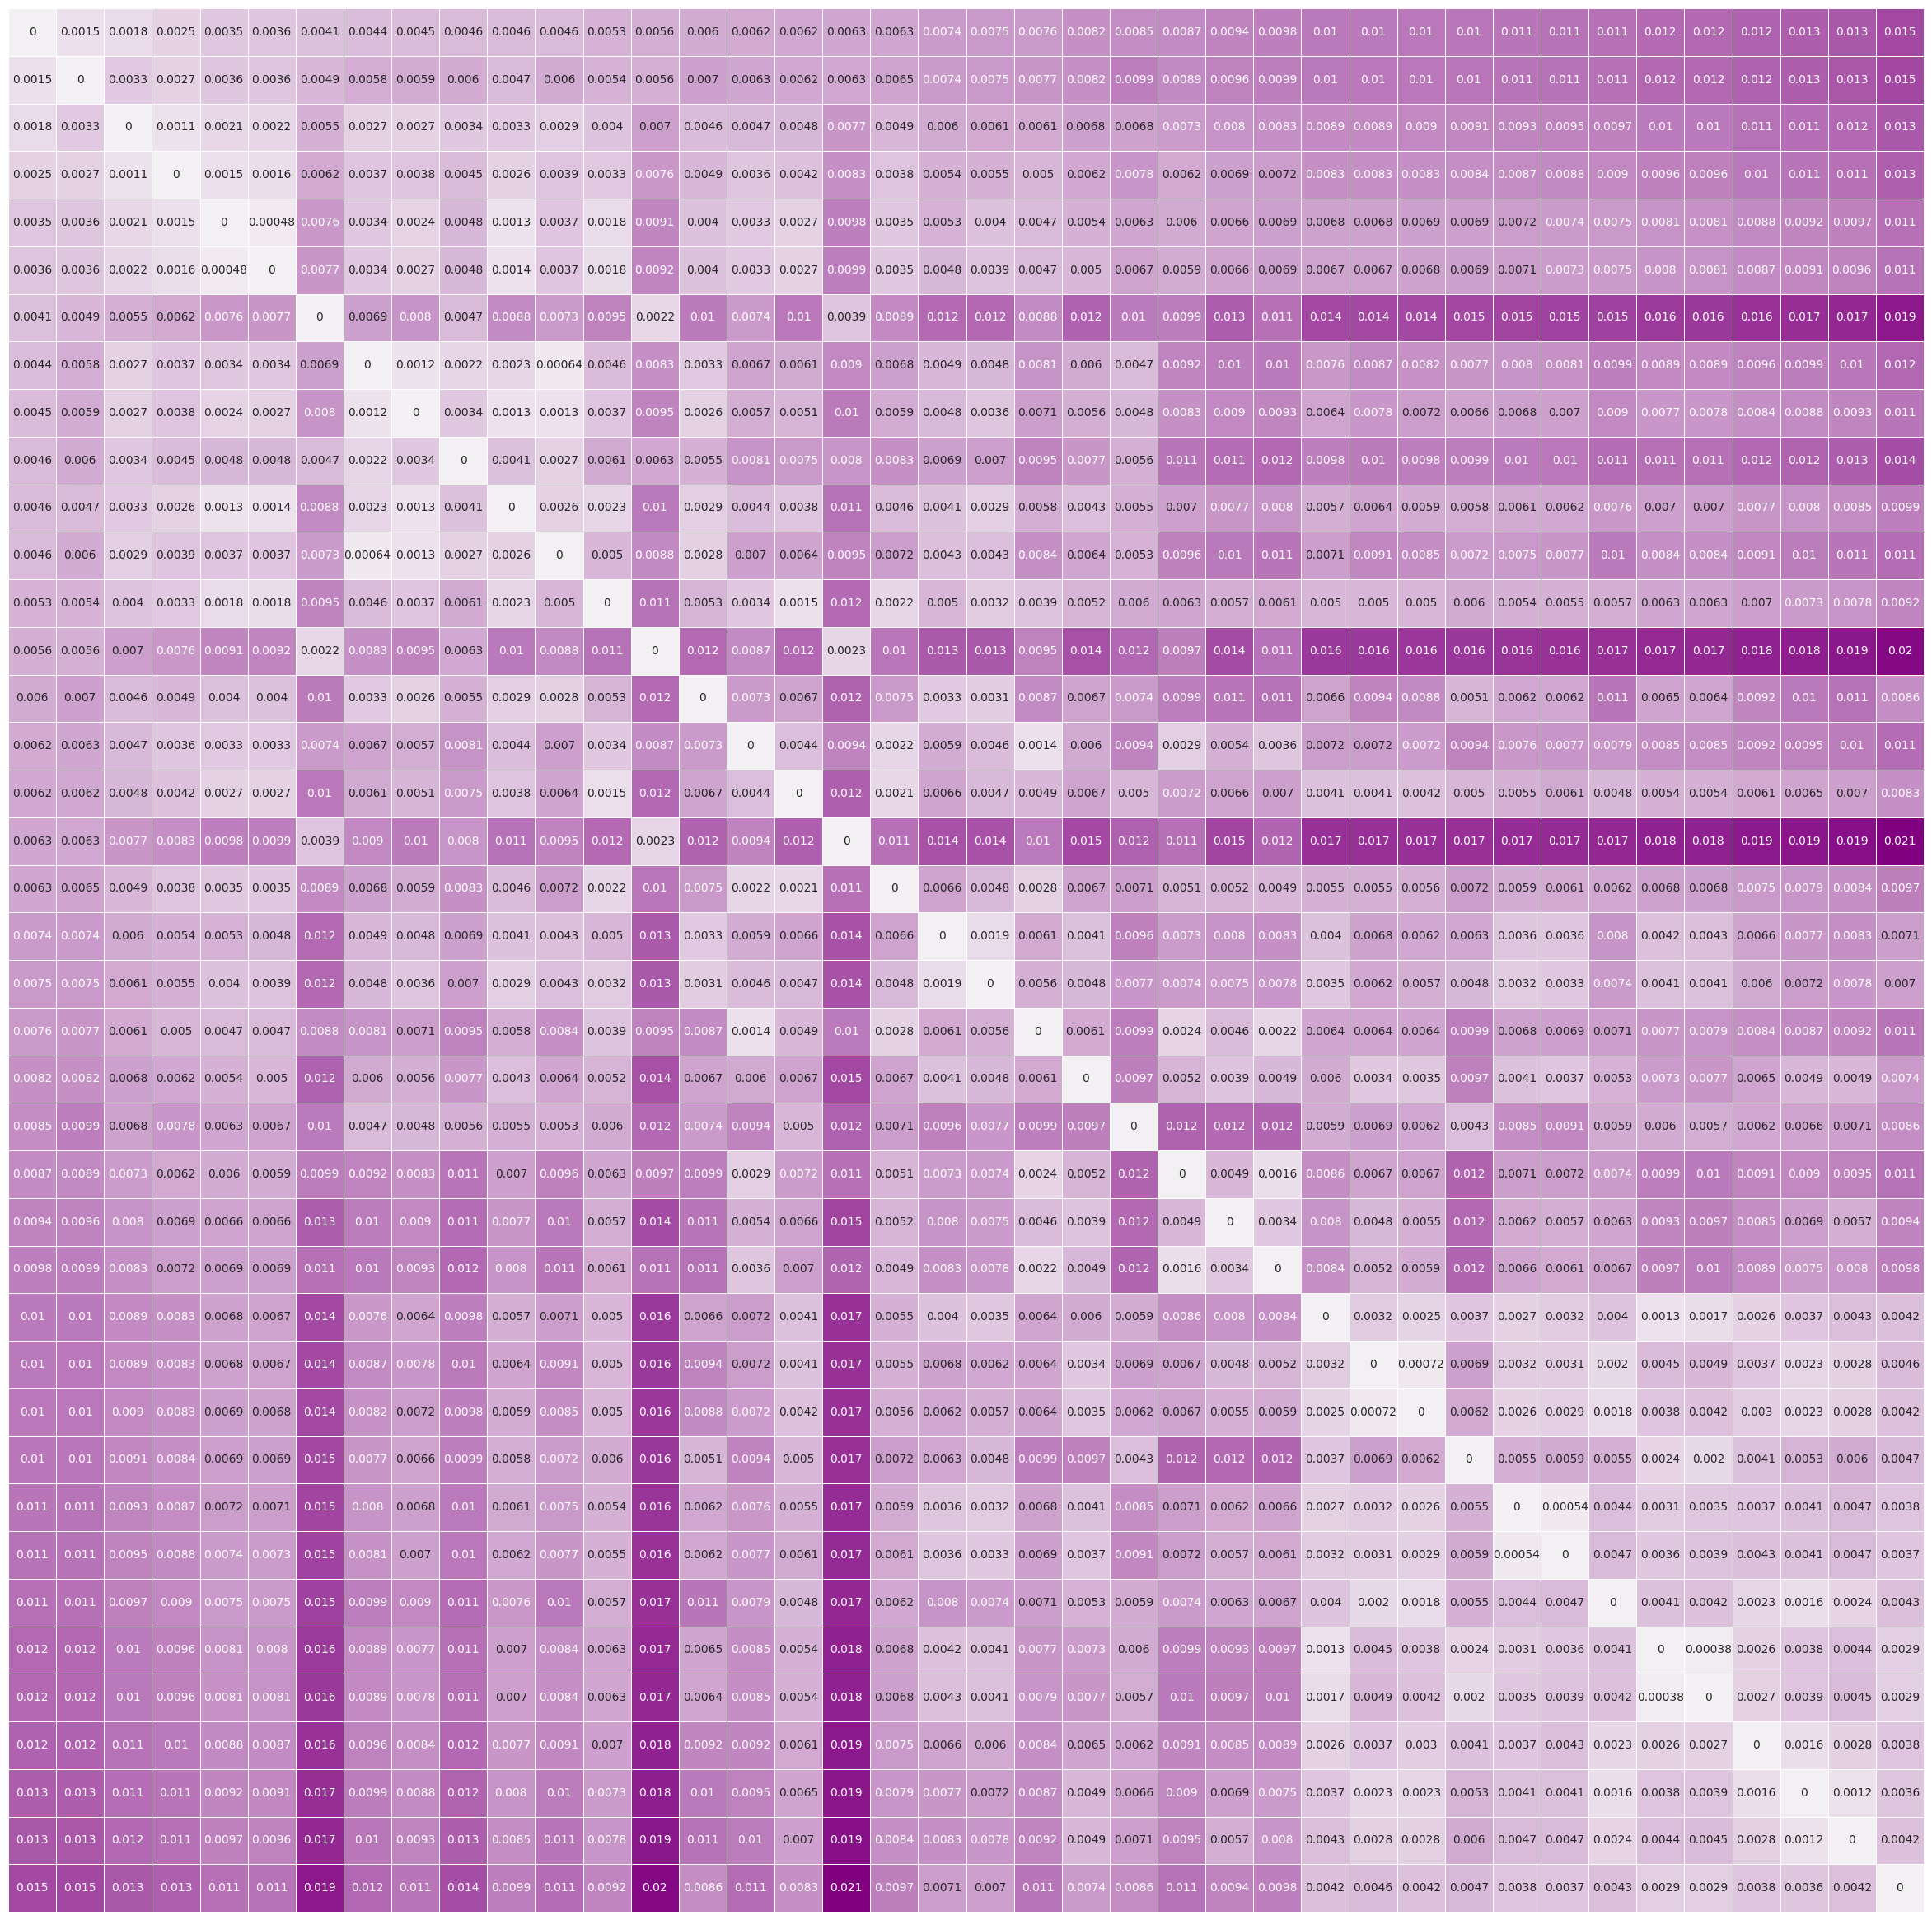

In [ ]:
# plt.figure(figsize=(30,30))
# purple_cmap = sns.light_palette("purple", as_cmap=True)
# sns.heatmap(df, annot=True, cmap=purple_cmap, linewidths=0.5, cbar=False, xticklabels=False, yticklabels=False)

In [ ]:
# sdfasdfasd

NameError: name 'sdfasdfasd' is not defined

In [24]:
# with open("ward_to_coords_emd_new_opt_2_bloc_50k_solid_new.pkl", "wb") as f:
#     pickle.dump(ward_to_coords, f)
    
ward_to_coords = pickle.load(open("ward_to_coords_emd_new_opt_2_bloc_50k_solid_new.pkl", "rb"))

In [ ]:
# for key, val in ward_to_coords.items():
#     ward_to_coords[key] = dict(reversed(list(val.items())))

In [ ]:
# len(ward_to_coords['aberdeen ward_11 2017']["n-PL"][0])

In [ ]:
# ward_to_coords[('aberdeen', 2017, 11)]['IAC'] = (ward_to_coords[('aberdeen', 2017, 11)]['IAC'][0][:20], ward_to_coords[('aberdeen', 2017, 11)]['IAC'][1][:20])
# ward_to_coords[('aberdeen', 2017, 11)]['IC'] = (ward_to_coords[('aberdeen', 2017, 11)]['IC'][0][:20], ward_to_coords[('aberdeen', 2017, 11)]['IC'][1][:20])
# ward_to_coords[('aberdeen', 2017, 11)]['IC'][0] = ward_to_coords[('aberdeen', 2017, 11)]['IC'][0][:20]
# ward_to_coords[('aberdeen', 2017, 11)]['IC'][1] = ward_to_coords[('aberdeen', 2017, 11)]['IC'][1][:20]

In [ ]:
# len(ward_to_coords[('aberdeen', 2017, 11)]['IC'][0])

40

In [27]:
for k, (x, y) in ward_to_coords[('aberdeen', 2017, 11)].items():
    ward_to_coords[('aberdeen', 2017, 11)][k] = (np.round(x, 5), np.round(y, 5))

aberdeen ward_11 2017


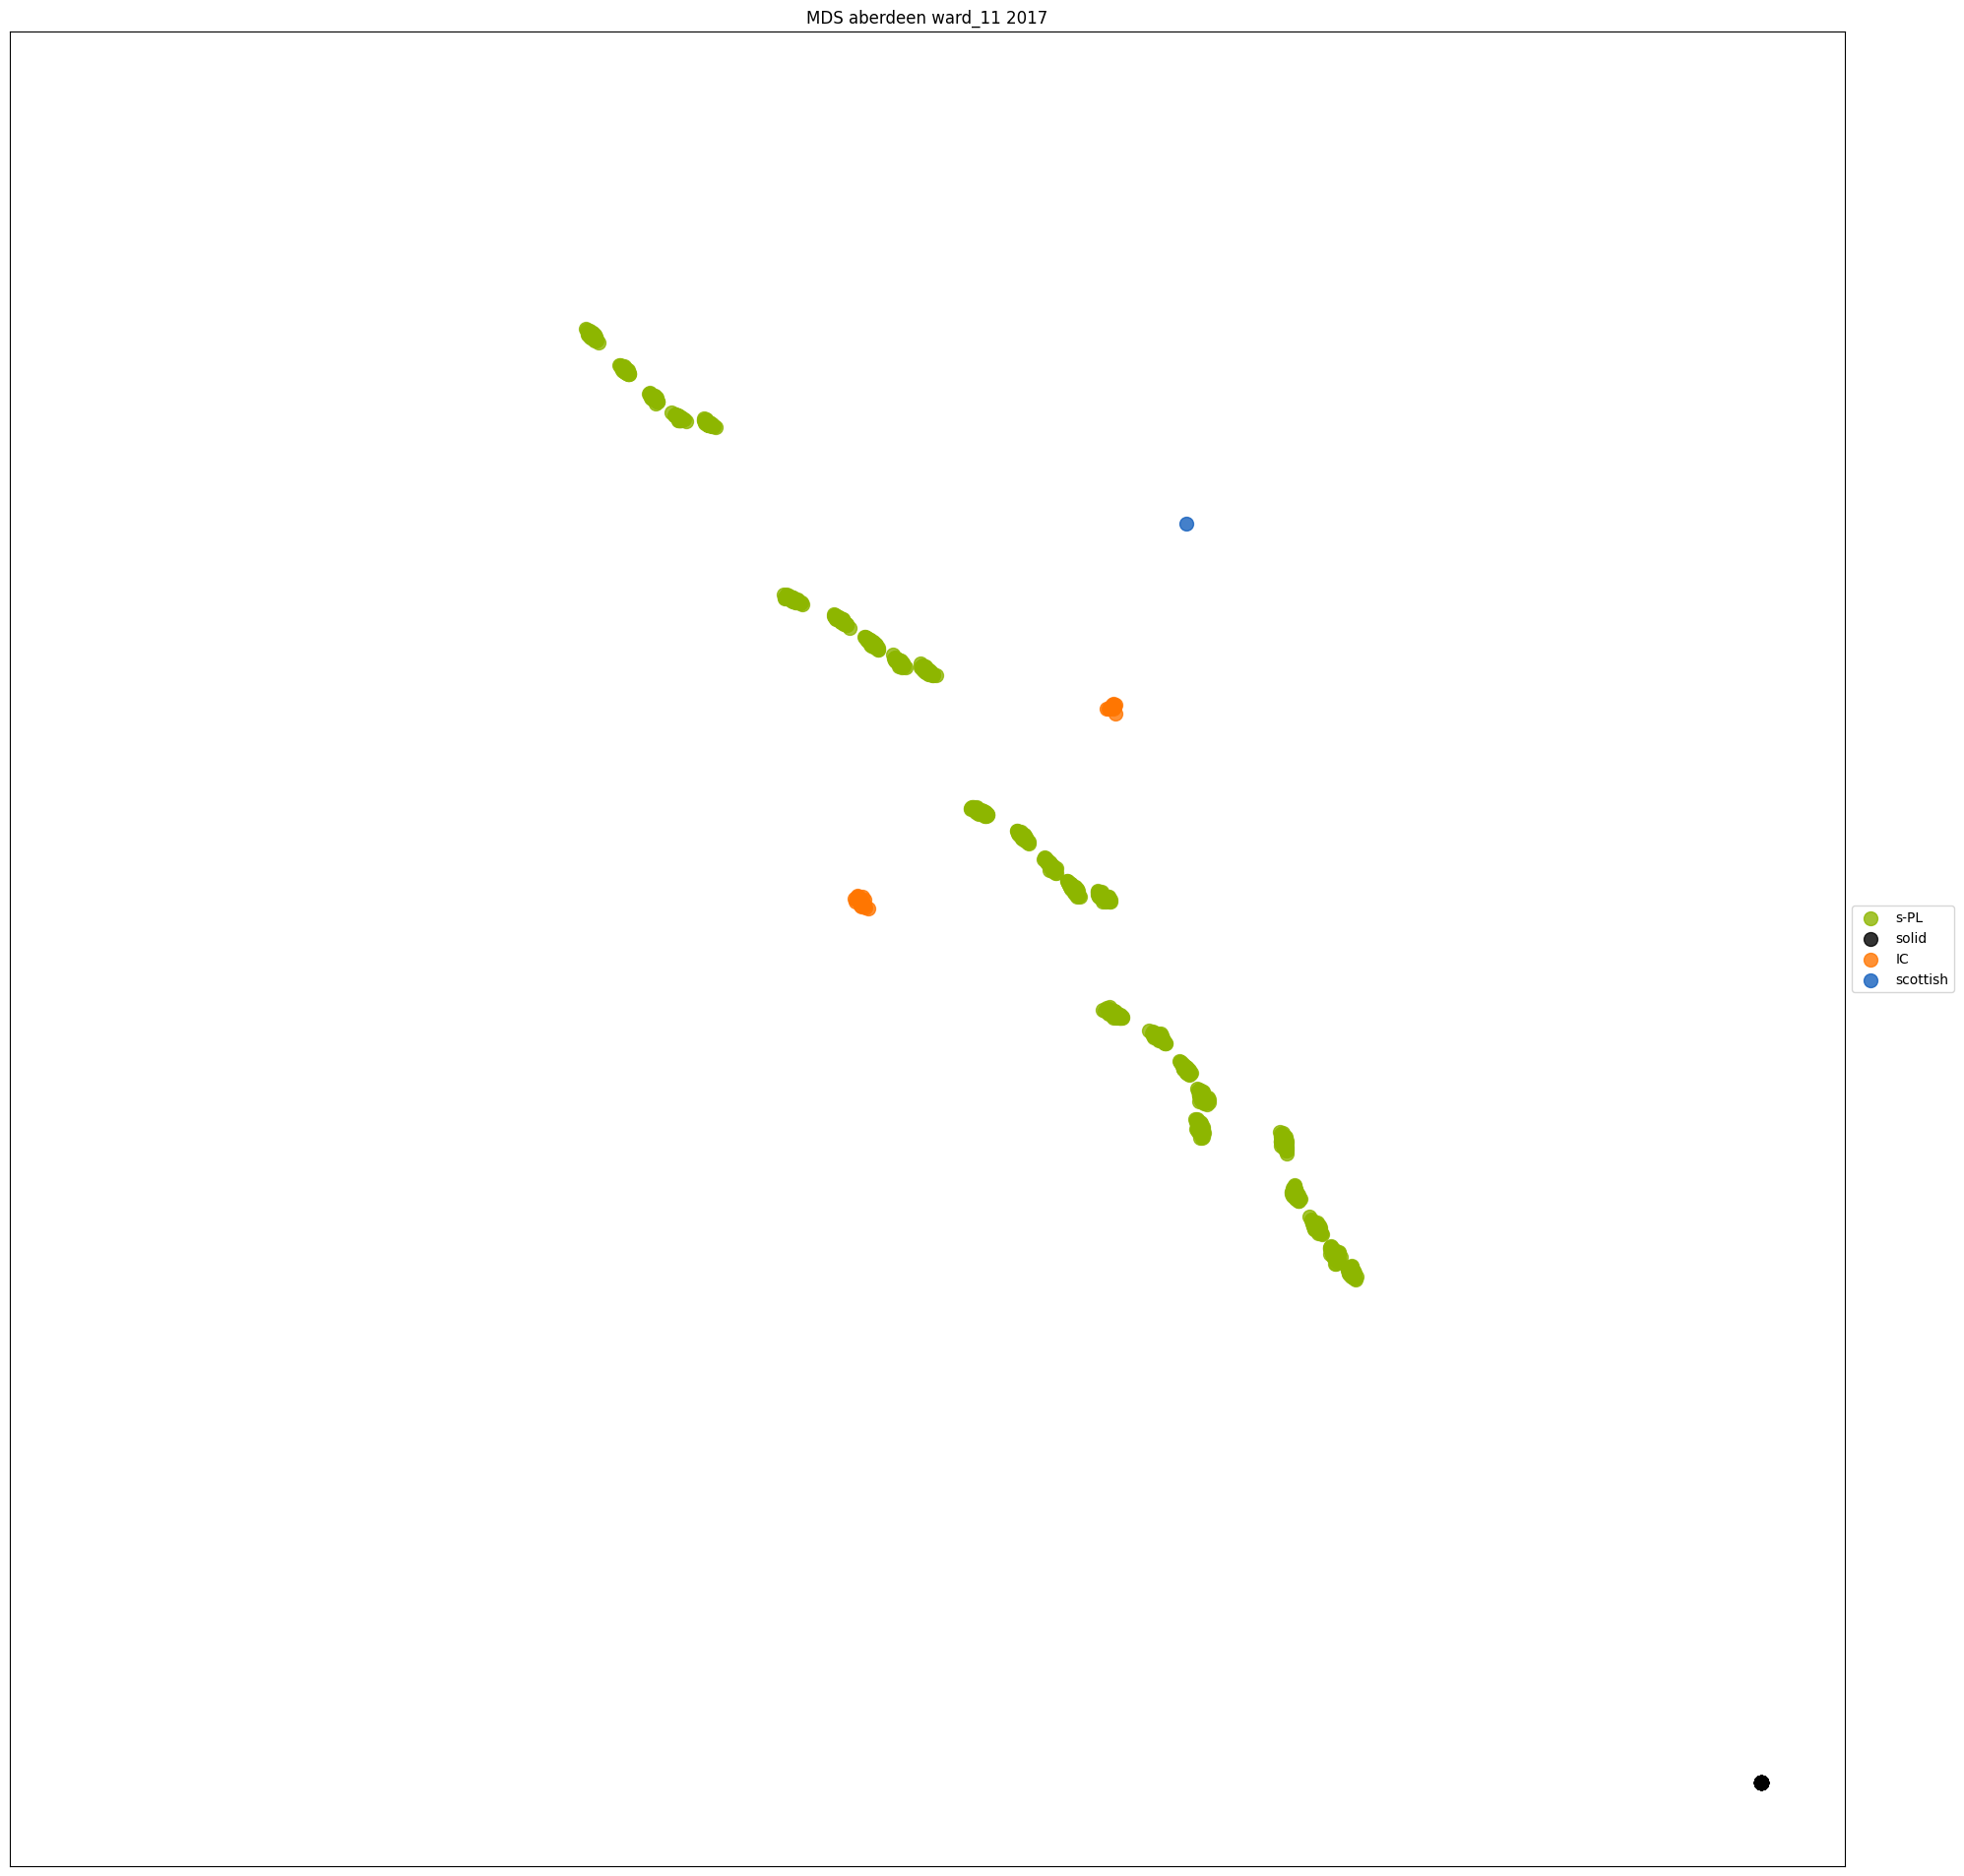

<Figure size 640x480 with 0 Axes>

In [28]:
# for key, file_name in [(("aberdeen", 2022, 11), "../election_data/aberdeen_2022_ward11.csv")]:

model_to_color = {
    's-PL': '#8DB600',
    "scottish": "#1560BD", 
    "IC":"#FF7601",
    "s-PL-peter": "#00FFFF",
    "solid": "#000",
    "IAC":"#929292" 
}

for key, file_name in list(file_names.items())[:1]:  
    city, year, ward = key
    
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)
    plot_kwarg_dict={m:{"c":color, "s":100, "alpha": 0.8 } for m, color in model_to_color.items()}
    plot_kwarg_dict.update({ward_label: {"c": scottish_color, "s":50}})
    
    ax = plot_MDS(coord_dict=ward_to_coords[key], 
                    plot_kwarg_dict=plot_kwarg_dict,
                    legend = True, title = True)
    
    # ax.figure.set_size_inches(100, 100)
    ax.figure.set_size_inches(20,20)

    
    ax.legend(bbox_to_anchor=(1, .5), loc="center left")
    plt.title(f"MDS {ward_label}")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"figures/MDS/emd_opt_mds_50k_{ward_label.replace(' ', '_')}_2_bloc_solid_all.png",bbox_inches='tight', dpi=300)
    plt.clf()

In [ ]:
# for key, file_name in file_names.items():
#     scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
#     print(scottish_profile.num_ballots(), num_seats, len(cand_list))

6116 3 4


In [ ]:
# idx1 = [2, 17, 22, 24]
# idx2 = [11, 15, 7, 27]

In [ ]:
# test_profile = ward_to_profile[('aberdeen', 2017, 11)]["s-PL"][0]

# from votekit.utils import borda_scores

# def get_bord_slate(profile):
#     borda_portions = borda_scores(profile)
#     norm_slate = {"A": 0, "B": 0}
#     for k, v in borda_portions.items():
#         norm_slate[k.split("_")[0]] += v
        
#     norm_slate = {k: float(v/sum(norm_slate.values())) for k, v in norm_slate.items()}
#     return norm_slate


In [ ]:
# prof_list = ward_to_profile[('aberdeen', 2017, 11)]["IC"]
# bord_b1 = []
# bord_b2 = []

# for i in idx1:
#     bord_b1.append(get_bord_slate(prof_list[i]))    
    
# for i in idx2:
#     bord_b2.append(get_bord_slate(prof_list[i]))
    
# print("cluster1")
# for item in bord_b1:
#     print(f"\t{item}")

# print("cluster2") 
# for item in bord_b2:
#     print(f"\t{item}")    

cluster1
	{'A': 0.250378, 'B': 0.749622}
	{'A': 0.250166, 'B': 0.749834}
	{'A': 0.250124, 'B': 0.749876}
	{'A': 0.24966, 'B': 0.75034}
cluster2
	{'A': 0.249906, 'B': 0.750094}
	{'A': 0.2492, 'B': 0.7508}
	{'A': 0.249062, 'B': 0.750938}
	{'A': 0.250196, 'B': 0.749804}
